In [1]:
import pandas as pd
import numpy as np
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt


In [2]:
DATA_DIR = Path(".")

files = {
    "Arges": DATA_DIR / "river_arges_data.csv",
    "Vedea": DATA_DIR / "river_vedea_data.csv",
    # "Dambovita": DATA_DIR / "river_dambovita_data.csv",
}

In [17]:

def strip_accents(text):
    if pd.isna(text):
        return np.nan
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    return "".join(c for c in text if not unicodedata.combining(c))

def clean_text(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = " ".join(text.split())
    return text

def to_float_ro(x):
    """Transformă valori de tip '27,0', '1,34', '-' în float."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["", "-", "nan", "NaN", "None"]:
        return np.nan
    x = x.replace(",", ".")
    try:
        return float(x)
    except ValueError:
        return np.nan

def standardize_station(station):
    s = clean_text(station)
    s_ascii = strip_accents(s).lower().replace(" ", "")

    if "maluspart" in s_ascii or "mauspart" in s_ascii:
        return "Malu Spart"
    if "alexandria" in s_ascii:
        return "Alexandria"
    if "malucuflor" in s_ascii or "maucuflor" in s_ascii:
        return "Malu cu Flori"
    if "campeni" in s_ascii or "camperi" in s_ascii:
        return "Campeni"

    return s

def standardize_river(row):
    river = clean_text(row["raul"])
    river_ascii = strip_accents(river).lower().replace(" ", "")

    if "arges" in river_ascii:
        return "Argeș"
    if "vedea" in river_ascii:
        return "Vedea"
    if "dambov" in river_ascii:
        return "Dâmbovița"
    if "aries" in river_ascii:
        return "Arieș"

    return river

dfs = []

for river_name, path in files.items():
    df = pd.read_csv(path)

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["raul_standard"] = df.apply(standardize_river, axis=1)
    df["statia_standard"] = df["statia_hidrometrica"].apply(standardize_station)

    numeric_cols = [
        "CA_cm", "CI_cm", "CP_cm",
        "Qmed_apr_m3_s",
        "diag_H_cm", "diag_Q_m3_s", "diag_dH_cm",
        "prog_H_cm", "prog_Q_m3_s", "prog_dH_cm",
    ]

    for col in numeric_cols:
        df[col] = df[col].apply(to_float_ro)

    # Shift prognoza columns one day earlier
    # prog_columns = [col for col in df.columns if col.startswith("prog_")]
    # for col in prog_columns:
    #     df[col] = df[col].shift(1).bfill()

    prog_df = df[["date", "raul_matched", "prog_H_cm", "prog_Q_m3_s"]].copy()
    prog_df["date"] = prog_df["date"] + pd.Timedelta(days=1)
    df = df.drop(columns=["prog_H_cm", "prog_Q_m3_s"]).merge(prog_df, on=["date", "raul_matched"])

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Păstrăm doar cele 3 râuri/stații relevante pentru tema Argeș–Vedea
main_data = data[
    (
        (data["raul_standard"] == "Argeș") &
        (data["statia_standard"] == "Malu Spart")
    ) |
    (
        (data["raul_standard"] == "Vedea") &
        (data["statia_standard"] == "Alexandria")
    ) |
    (
        (data["raul_standard"] == "Dâmbovița") &
        (data["statia_standard"] == "Malu cu Flori")
    )
].copy()

# Indicatori derivați
main_data["pct_CA_diag"] = main_data["diag_H_cm"] / main_data["CA_cm"] * 100
main_data["pct_CI_diag"] = main_data["diag_H_cm"] / main_data["CI_cm"] * 100
main_data["pct_CP_diag"] = main_data["diag_H_cm"] / main_data["CP_cm"] * 100

main_data["Q_ratio_diag"] = main_data["diag_Q_m3_s"] / main_data["Qmed_apr_m3_s"]
main_data["Q_ratio_prog"] = main_data["prog_Q_m3_s"] / main_data["Qmed_apr_m3_s"]

# Clasificare simplă a nivelului de risc
def risk_class(pct_ca):
    if pd.isna(pct_ca):
        return np.nan
    if pct_ca >= 100:
        return "depășire CA"
    if pct_ca >= 80:
        return "foarte ridicat"
    if pct_ca >= 50:
        return "ridicat"
    return "normal"

main_data["risk_class"] = main_data["pct_CA_diag"].apply(risk_class)

In [18]:
main_data.loc[main_data["date"] == "2025-12-25", ["date", "raul", "diag_H_cm", "prog_H_cm"]]

,date,raul,diag_H_cm,prog_H_cm
921,2025-12-25,Argeș,456.0,164.0
1956,2025-12-25,Vedea,123.0,124.0


In [19]:
main_data[["date", "diag_H_cm", "prog_H_cm"]].query("date == '2025-12-25'")

,date,diag_H_cm,prog_H_cm


In [20]:

# Rezumat pe râu/stație
summary = (
    main_data
    .groupby(["raul_standard", "statia_standard"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_obs=("date", "count"),
        H_max=("diag_H_cm", "max"),
        Q_max=("diag_Q_m3_s", "max"),
        CA=("CA_cm", "median"),
        CI=("CI_cm", "median"),
        CP=("CP_cm", "median"),
        pct_CA_max=("pct_CA_diag", "max"),
        Q_ratio_max=("Q_ratio_diag", "max"),
    )
    .reset_index()
)

summary

,raul_standard,statia_standard,start_date,end_date,n_obs,H_max,Q_max,CA,CI,CP,pct_CA_max,Q_ratio_max
0,Argeș,Malu Spart,2022-12-31,2026-04-19,998,456.0,585.0,510.0,540.0,600.0,89.411765,22.674419
1,Vedea,Alexandria,2022-12-31,2026-04-19,1000,300.0,136.0,380.0,500.0,550.0,78.947368,10.746479


In [21]:
# Top episoade după apropierea de cota de atenție
top_events = (
    main_data
    .sort_values("pct_CA_diag", ascending=False)
    [[
        "date", "raul_standard", "statia_standard",
        "diag_H_cm", "diag_Q_m3_s",
        "CA_cm", "CI_cm", "CP_cm",
        "pct_CA_diag", "Q_ratio_diag", "risk_class"
    ]]
    .head(15)
)

top_events

,date,raul_standard,statia_standard,diag_H_cm,diag_Q_m3_s,CA_cm,CI_cm,CP_cm,pct_CA_diag,Q_ratio_diag,risk_class
921,2025-12-25,Argeș,Malu Spart,456.0,585.00,510.0,540.0,600.0,89.411765,22.674419,foarte ridicat
296,2023-12-27,Argeș,Malu Spart,185.0,16.50,210.0,240.0,300.0,88.095238,0.639535,foarte ridicat
273,2023-11-26,Argeș,Malu Spart,181.0,18.10,210.0,240.0,300.0,86.190476,0.726908,foarte ridicat
208,2023-09-08,Argeș,Malu Spart,180.0,8.52,210.0,240.0,300.0,85.714286,0.387273,foarte ridicat
2011,2026-02-26,Vedea,Alexandria,300.0,78.00,380.0,500.0,550.0,78.947368,5.379310,ridicat
900,2025-12-02,Argeș,Malu Spart,390.0,433.00,510.0,540.0,600.0,76.470588,16.782946,ridicat
899,2025-12-01,Argeș,Malu Spart,358.0,359.00,510.0,540.0,600.0,70.196078,13.914729,ridicat
2006,2026-02-21,Vedea,Alexandria,258.0,56.50,380.0,500.0,550.0,67.894737,3.896552,ridicat
2012,2026-02-27,Vedea,Alexandria,250.0,53.00,380.0,500.0,550.0,65.789474,3.655172,ridicat
1065,2023-02-27,Vedea,Alexandria,192.0,69.30,300.0,400.0,500.0,64.000000,4.149701,ridicat


In [22]:
# Salvare pentru verificare / tabele în proiect
main_data.to_csv("hydro_arges_vedea_clean.csv", index=False)
summary.to_csv("hydro_summary.csv", index=False)
top_events.to_csv("hydro_top_events.csv", index=False)

In [24]:
# Compate performance prognoza vs diagnoza
main_data["prog_error_H_cm"] = main_data["prog_H_cm"] - main_data["diag_H_cm"]
main_data["prog_abs_error_H_cm"] = np.abs(main_data["prog_H_cm"] - main_data["diag_H_cm"])
main_data["prog_abs_error_Q_m3_s"] = np.abs(main_data["prog_Q_m3_s"] - main_data["diag_Q_m3_s"])

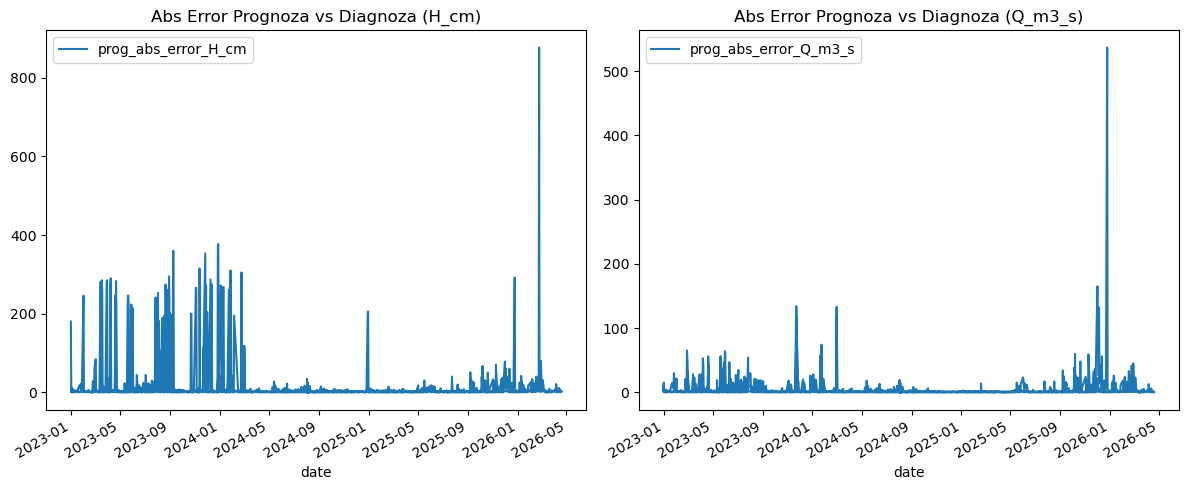

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
main_data[["date", "prog_abs_error_H_cm"]].plot.line(x="date", y="prog_abs_error_H_cm", ax=ax[0], title="Abs Error Prognoza vs Diagnoza (H_cm)")
main_data[["date", "prog_abs_error_Q_m3_s"]].plot.line(x="date", y="prog_abs_error_Q_m3_s", ax=ax[1], title="Abs Error Prognoza vs Diagnoza (Q_m3_s)")
plt.tight_layout()
plt.show()

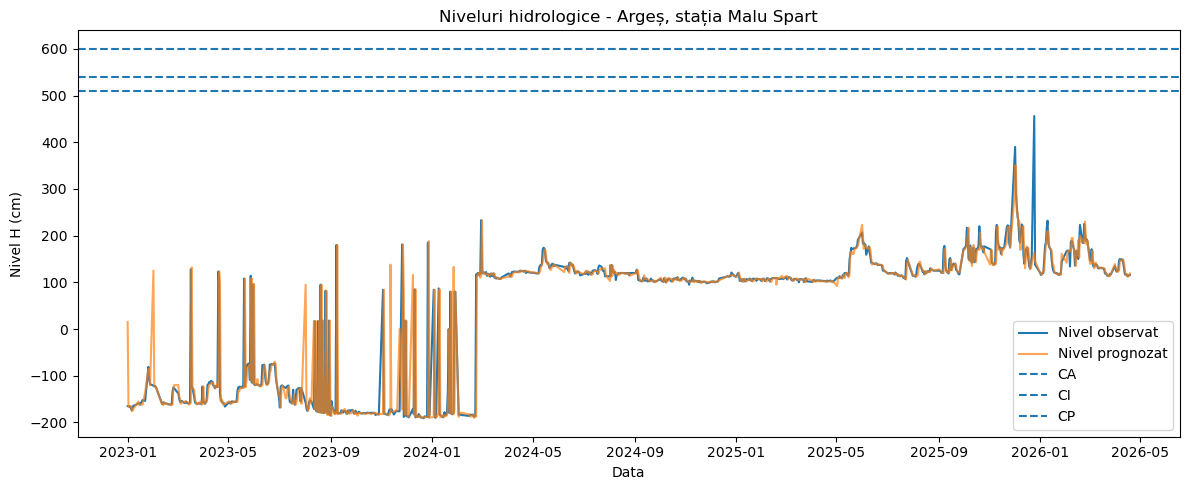

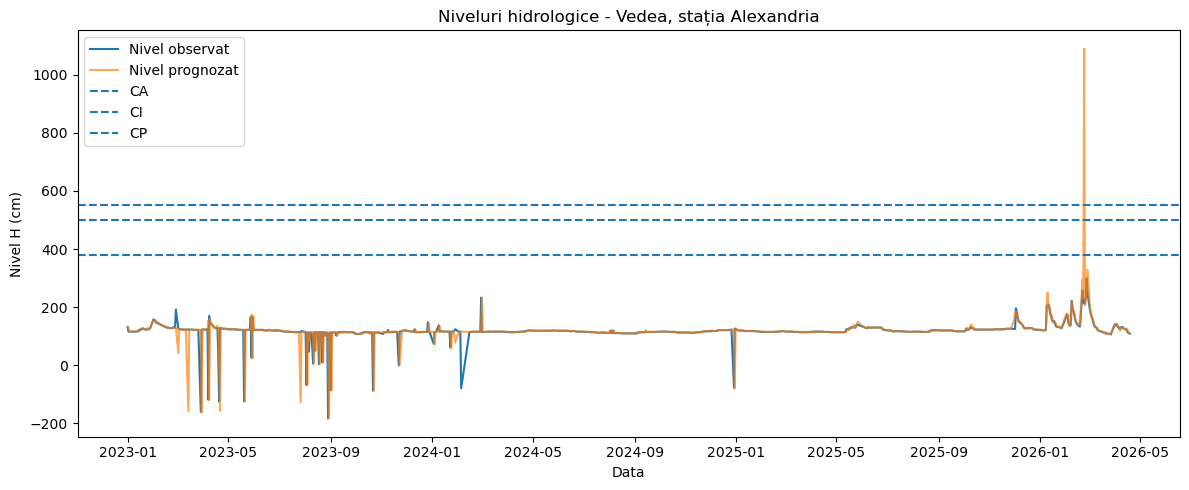

In [23]:

for (river, station), g in main_data.groupby(["raul_standard", "statia_standard"]):
    g = g.sort_values("date")

    plt.figure(figsize=(12, 5))
    plt.plot(g["date"], g["diag_H_cm"], label="Nivel observat")
    plt.plot(g["date"], g["prog_H_cm"], label="Nivel prognozat", alpha=0.7)

    ca = g["CA_cm"].median()
    ci = g["CI_cm"].median()
    cp = g["CP_cm"].median()

    plt.axhline(ca, linestyle="--", label="CA")
    plt.axhline(ci, linestyle="--", label="CI")
    plt.axhline(cp, linestyle="--", label="CP")

    plt.title(f"Niveluri hidrologice - {river}, stația {station}")
    plt.xlabel("Data")
    plt.ylabel("Nivel H (cm)")
    plt.legend()
    plt.tight_layout()
    plt.show()